In [3]:
1+1

2

# Validate sHPFC SIM

## Imports

In [4]:
# Add parent folder (project root) to sys.path so notebook can import modules
import sys
from pathlib import Path
project_root = Path.cwd().parent.resolve()
if str(project_root / 'HPFC') not in sys.path:
    sys.path.insert(0, str(project_root / 'HPFC'))
print('Added to sys.path:', str(project_root / 'HPFC'))

Added to sys.path: E:\HPC\PFC-test\26140\HPFC


In [5]:
# numeric math
import math

# array numerics
import numpy as np  # for CPU
import cupy as cp   # for CUDA GPU

# PFC
import PFC2D_model, PFC2D_geometry, PFC2D_kernels
import sHPFC

# interactive plotting
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "png" # Set default renderer to PNG for static images in notebooks

In [6]:
from importlib import reload
reload(PFC2D_model)
reload(PFC2D_geometry)
reload(PFC2D_kernels)
reload(sHPFC)

<module 'sHPFC' from 'E:\\HPC\\PFC-test\\26140\\HPFC\\sHPFC.py'>

## Plotting helper

In [7]:
def GetDensityHeatmap(field, X, Y):
  print(field.min(), field.max(), field.mean(), field.std())

  fig = go.Figure()
  fig.add_trace(go.Heatmap(z=field, x=X[0,:], y=Y[:,0], colorscale='haline', showscale=False))
  # make axis use same scale, keep it square
  # fig.update_xaxes(scaleanchor = "y", scaleratio = 1)

  # hide axis labels
  fig.update_xaxes(
    showticklabels=False,
    showgrid=False,
    zeroline=False
  )
  fig.update_yaxes(
    showticklabels=False,
    showgrid=False,
    zeroline=False
  )

  # zero margins
  fig.update_layout(margin=dict(l=0, r=0, t=0, b=0))

  # figure size 100x100
  fig.update_layout(
    width=600,
    height=600*Y.max()/X.max()
  )

  return fig


## Perfect Crystal Validation

### 1) Setup a uniform crystal with inital guess for $A_0$

In [8]:
# Geometry
q1 = np.array([-3**0.5/2,-0.5])
q2 = np.array([3**0.5/2,-0.5])
q3 = np.array([0,1])
a = 4*np.pi/3**0.5
h = 4*np.pi
psi0 = -0.265
A0 = 0.3162

Mx = 200
My = 111

Nx = 1600
Ny = 1600
Lx = a*Mx
Ly = h*My

X, Y = np.meshgrid(np.linspace(0,Lx,Nx,endpoint=False),np.linspace(0,Ly,Ny,endpoint=False))
dx = X[0,1]
dy = Y[1,0]

In [9]:
psi = (
    psi0 +
    A0 * np.exp(1.j * (q1[0]*X + q1[1]*Y)) + A0 * np.exp(-1.j * (q1[0]*X + q1[1]*Y)) +
    A0 * np.exp(1.j * (q2[0]*X + q2[1]*Y)) + A0 * np.exp(-1.j * (q2[0]*X + q2[1]*Y)) +
    A0 * np.exp(1.j * (q3[0]*X + q3[1]*Y)) + A0 * np.exp(-1.j * (q3[0]*X + q3[1]*Y))
).real

-1.2135983733718887 1.6322 -0.26500000000000135 0.7745286566680396


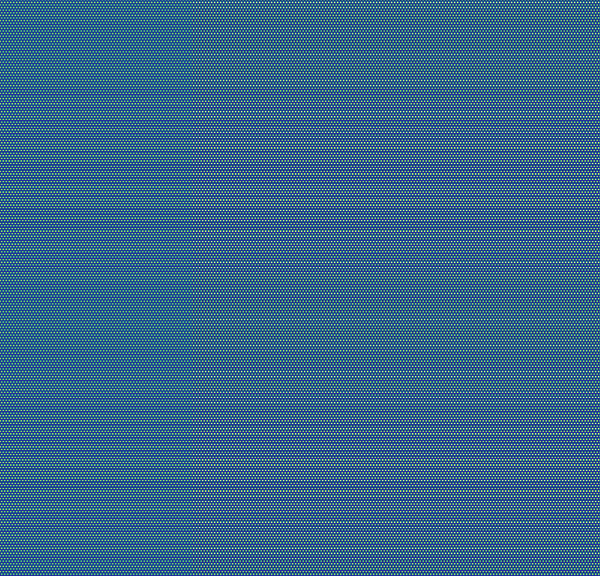

In [10]:
GetDensityHeatmap(psi, X, Y).show()

-0.08381810630107105 1.2916521683615456 0.15691186909616572 0.2158540656792064


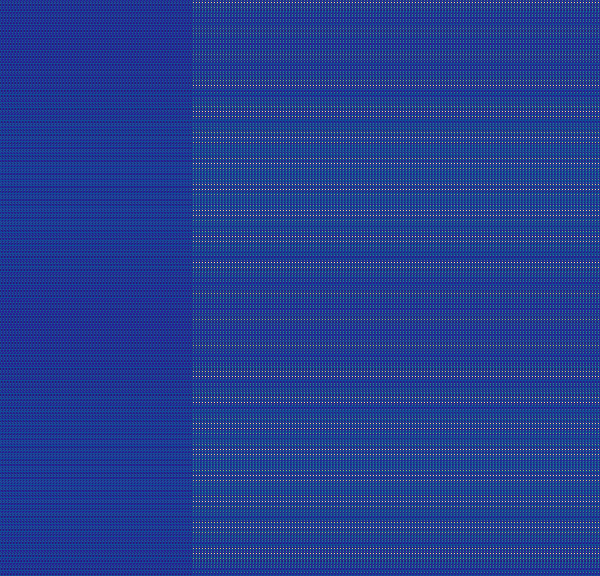

-1.8096935095938975 3.756866218254678 -0.3281524934640031 0.8953088061506285


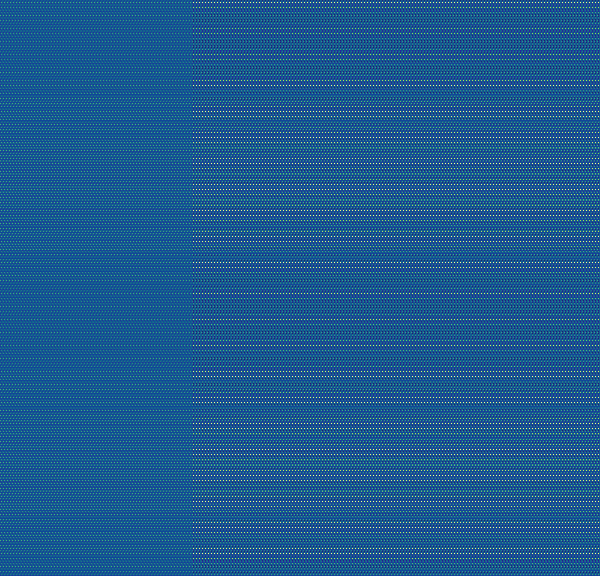

In [11]:
model = PFC2D_model.model_2D(temp=-0.2, beta=1.0, Gamma = 1.0, rho0 = 2.**(-6), Gamma_s = 2.**(-6), dt=1e-6)
geometry = PFC2D_geometry.geometry_2D((Nx, Ny), Lx, Ly)
sim = sHPFC.sHPFC(psi0 = psi, model = model, geometry = geometry)

sim.calc_f()
GetDensityHeatmap(sim.f.get(), X, Y).show()
sim.calc_mu()
GetDensityHeatmap(sim.mu.get(), X, Y).show()

### 2) Relax crystal
- Expect $f$ monotonically decreases.
- Expect $\mu$ converges

In [ ]:
model = PFC2D_model.model_2D(temp=-0.2, beta=1.0, Gamma = 1.0, rho0 = 2.**(-6), Gamma_s = 2.**(-6), dt=0.1)
geometry = PFC2D_geometry.geometry_2D((Nx, Ny), Lx, Ly)
sim = sHPFC.sHPFC(psi0 = psi, model = model, geometry = geometry)

sim.calc_f()
sim.calc_mu()

psi_t = np.zeros((31, *psi.shape), dtype=np.float64)
f_t = np.zeros((31, *psi.shape), dtype=np.float64)
mu_t = np.zeros((31, *psi.shape), dtype=np.float64)
t = np.zeros(31, dtype=np.float64)
psi_t[0] = sim.psi.get()
f_t[0] = sim.f.get()
mu_t[0] = sim.mu.get()
t[0] = sim.t

print(f'Initial t={t[0]:.8e}, f={f_t[0].mean():.8e}, σ_μ:{mu_t[0].std():.8e}')
for i in range(30):
  for _ in range(10):
    sim.Timestep_sHPFC()
  sim.calc_f()
  sim.calc_mu()
  psi_t[i+1] = sim.psi.get()
  f_t[i+1] = sim.f.get()
  mu_t[i+1] = sim.mu.get()
  t[i+1] = sim.t
  print(f't={sim.t:.8e} Δf={(f_t[i+1] - f_t[i]).mean():.8e} Δσ_μ:{mu_t[i+1].std() - mu_t[i].std():.8e}')


Initial t=0.00000000e+00, f=1.56911869e-01, σ_μ:8.95308806e-01
t=3.00000000e+00 Δf=-1.27109101e-01 Δσ_μ:-8.66583517e-01
t=6.00000000e+00 Δf=-9.56892699e-04 Δσ_μ:-1.89492512e-02
t=9.00000000e+00 Δf=-1.48160822e-04 Δσ_μ:-5.11904914e-03
t=1.20000000e+01 Δf=-3.78638106e-05 Δσ_μ:-2.12053306e-03
t=1.50000000e+01 Δf=-1.19289283e-05 Δσ_μ:-1.05912975e-03
t=1.80000000e+01 Δf=-4.18517235e-06 Δσ_μ:-5.84186047e-04
t=2.10000000e+01 Δf=-1.56035320e-06 Δσ_μ:-3.41204794e-04
t=2.40000000e+01 Δf=-6.03129524e-07 Δσ_μ:-2.06278966e-04
t=2.70000000e+01 Δf=-2.38332388e-07 Δσ_μ:-1.27389692e-04
t=3.00000000e+01 Δf=-9.54809060e-08 Δσ_μ:-7.97243106e-05
t=3.30000000e+01 Δf=-3.85829890e-08 Δσ_μ:-5.03139332e-05
t=3.60000000e+01 Δf=-1.56764418e-08 Δσ_μ:-3.19228227e-05
t=3.90000000e+01 Δf=-6.39170665e-09 Δσ_μ:-2.03241860e-05
t=4.20000000e+01 Δf=-2.61198147e-09 Δσ_μ:-1.29691652e-05
t=4.50000000e+01 Δf=-1.06895367e-09 Δσ_μ:-8.28763522e-06
t=4.80000000e+01 Δf=-4.37853475e-10 Δσ_μ:-5.29960274e-06
t=5.10000000e+01 Δf=-1.79

-0.5544230631787413 0.3555306536386793 -0.26500000000000135 0.24749726494227514


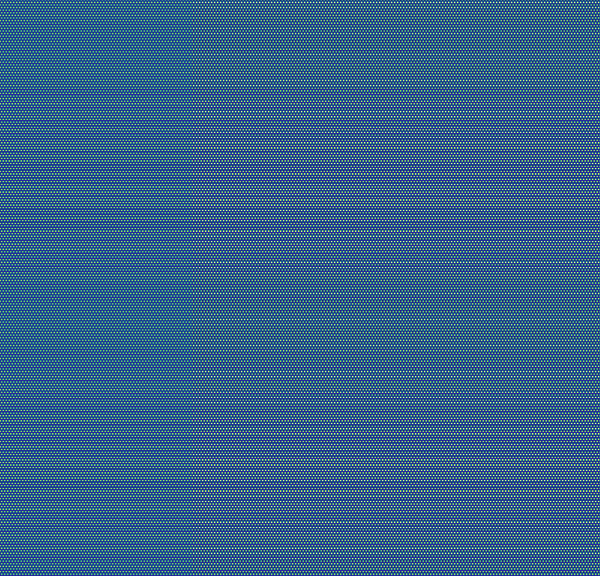

In [13]:
GetDensityHeatmap(psi_t[39], X, Y).show()

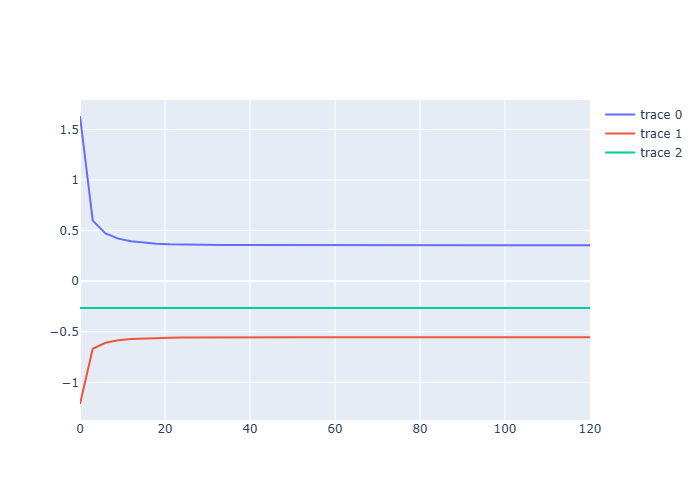

In [14]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=t, y=psi_t.max(axis=(-1,-2)), mode='lines'))
fig.add_trace(go.Scatter(x=t, y=psi_t.min(axis=(-1,-2)), mode='lines'))
fig.add_trace(go.Scatter(x=t, y=psi_t.mean(axis=(-1,-2)), mode='lines'))
fig.show()

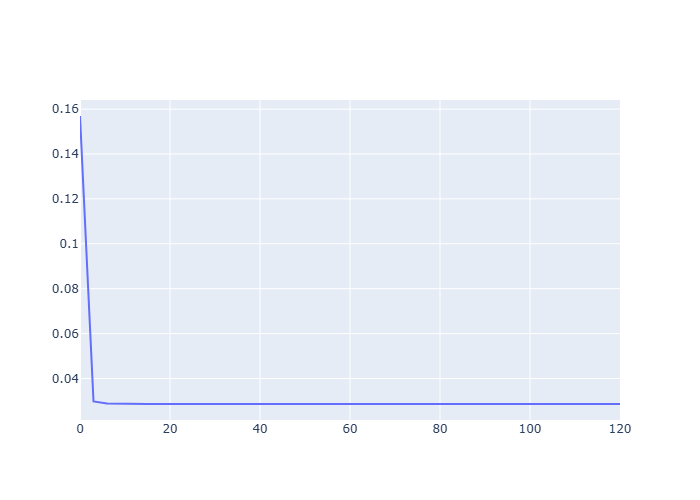

In [15]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=t, y=f_t.mean(axis=(-1,-2)), mode='lines'))
fig.show()

Resorting to unclean kill browser.


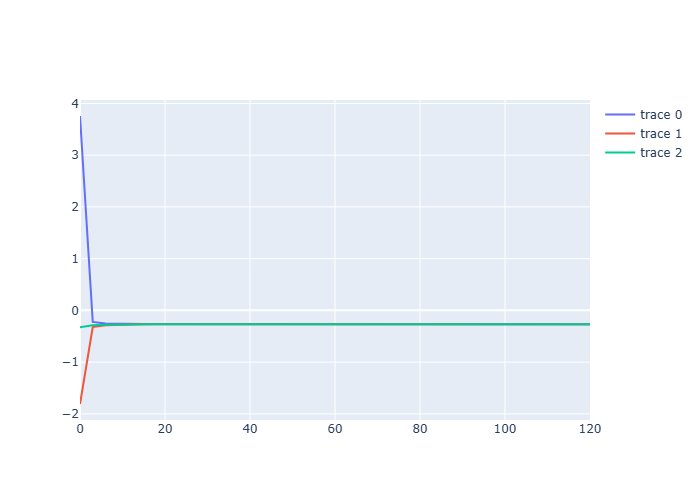

In [16]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=t, y=mu_t.max(axis=(-1,-2)), mode='lines'))
fig.add_trace(go.Scatter(x=t, y=mu_t.min(axis=(-1,-2)), mode='lines'))
fig.add_trace(go.Scatter(x=t, y=mu_t.mean(axis=(-1,-2)), mode='lines'))
fig.show()

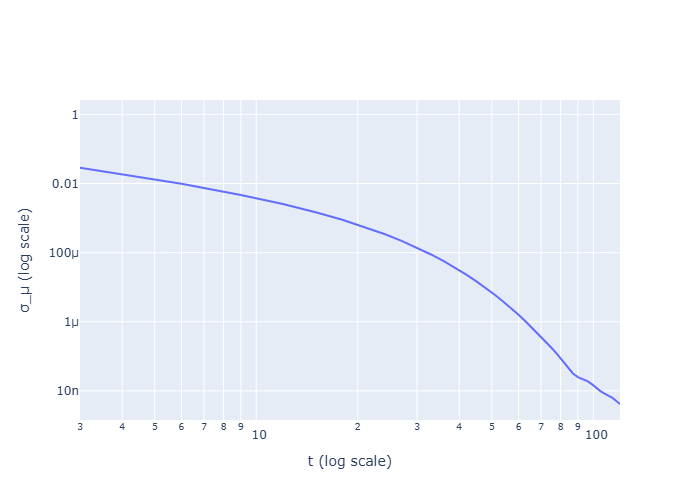

In [17]:
# log-log plot of std(μ) vs t
fig = go.Figure()
fig.add_trace(go.Scatter(x=t, y=mu_t.std(axis=(-1,-2)), mode='lines'))
fig.update_layout(
  xaxis=dict(
      title="t (log scale)",
      type="log",
      showgrid=True
  ),
  yaxis=dict(
      title="σ_μ (log scale)",
      type="log",
      showgrid=True
  ),
)
fig.show()

### 3) Stable $A_0^*$ Crystal Relaxation
- Expect $f$ monotonically decreases (to numeric limit).
- Expect $\mu$ converges (to numeric limit)

In [18]:
A0_star = (psi_t[-1].max() - psi_t[-1].min())/9
print(f'Relaxed A0: {A0_star}')

psi_A0_star = (
    psi0 +
    A0_star * np.exp(1.j * (q1[0]*X + q1[1]*Y)) + A0_star * np.exp(-1.j * (q1[0]*X + q1[1]*Y)) +
    A0_star * np.exp(1.j * (q2[0]*X + q2[1]*Y)) + A0_star * np.exp(-1.j * (q2[0]*X + q2[1]*Y)) +
    A0_star * np.exp(1.j * (q3[0]*X + q3[1]*Y)) + A0_star * np.exp(-1.j * (q3[0]*X + q3[1]*Y))
).real

Relaxed A0: 0.10110596871800265


In [20]:
model = PFC2D_model.model_2D(temp=-0.2, beta=1.0, Gamma = 1.0, rho0 = 2.**(-6), Gamma_s = 2.**(-6), dt=0.1)
geometry = PFC2D_geometry.geometry_2D((Nx, Ny), Lx, Ly)
sim = sHPFC.sHPFC(psi0 = psi_A0_star, model = model, geometry = geometry)

sim.calc_f()
sim.calc_mu()

frames = 30
psi_t_A0_star = np.zeros((frames+1, *psi.shape), dtype=np.float64)
f_t_A0_star = np.zeros((frames+1, *psi.shape), dtype=np.float64)
mu_t_A0_star = np.zeros((frames+1, *psi.shape), dtype=np.float64)
t = np.zeros(frames+1, dtype=np.float64)
psi_t_A0_star[0] = sim.psi.get()
f_t_A0_star[0] = sim.f.get()
mu_t_A0_star[0] = sim.mu.get()
t[0] = sim.t

print(f'Initial t={t[0]:.8e}, f={f_t_A0_star[0].mean():.8e}, σ_μ:{mu_t_A0_star[0].std():.8e}')
for i in range(frames):
  for _ in range(10):
    sim.Timestep_sHPFC()
  sim.calc_f()
  sim.calc_mu()
  psi_t_A0_star[i+1] = sim.psi.get()
  f_t_A0_star[i+1] = sim.f.get()
  mu_t_A0_star[i+1] = sim.mu.get()
  t[i+1] = sim.t
  print(f't={sim.t:.8e} Δf={(f_t_A0_star[i+1] - f_t_A0_star[i]).mean():.8e} Δσ_μ:{mu_t_A0_star[i+1].std() - mu_t_A0_star[i].std():.8e}')


Initial t=0.00000000e+00, f=2.87147806e-02, σ_μ:2.74038629e-02
t=1.00000000e+00 Δf=-7.36059256e-05 Δσ_μ:-2.73878788e-02
t=2.00000000e+00 Δf=-2.24883625e-10 Δσ_μ:-2.20947526e-06
t=3.00000000e+00 Δf=-1.67016493e-10 Δσ_μ:-1.90351630e-06
t=4.00000000e+00 Δf=-1.24048492e-10 Δσ_μ:-1.64014435e-06
t=5.00000000e+00 Δf=-9.21402580e-11 Δσ_μ:-1.41329475e-06
t=6.00000000e+00 Δf=-6.84430741e-11 Δσ_μ:-1.21788117e-06
t=7.00000000e+00 Δf=-5.08427064e-11 Δσ_μ:-1.04953161e-06
t=8.00000000e+00 Δf=-3.77697723e-11 Δσ_μ:-9.04486297e-07
t=9.00000000e+00 Δf=-2.80591589e-11 Δσ_μ:-7.79510772e-07
t=1.00000000e+01 Δf=-2.08457541e-11 Δσ_μ:-6.71821693e-07
t=1.10000000e+01 Δf=-1.54871518e-11 Δσ_μ:-5.79023335e-07
t=1.20000000e+01 Δf=-1.15063013e-11 Δσ_μ:-4.99053189e-07
t=1.30000000e+01 Δf=-8.54886826e-12 Δσ_μ:-4.30135309e-07
t=1.40000000e+01 Δf=-6.35169601e-12 Δσ_μ:-3.70740265e-07
t=1.50000000e+01 Δf=-4.71930446e-12 Δσ_μ:-3.19550762e-07
t=1.60000000e+01 Δf=-3.50649960e-12 Δσ_μ:-2.75432091e-07
t=1.70000000e+01 Δf=-2.60

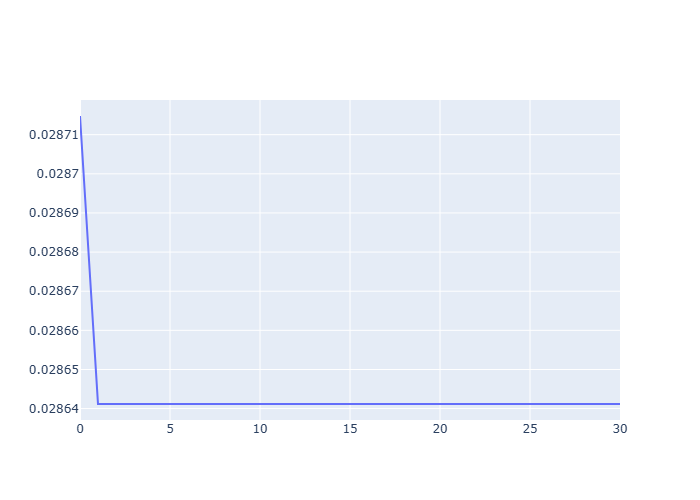

In [21]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=t, y=f_t_A0_star.mean(axis=(-1,-2)), mode='lines'))
fig.show()

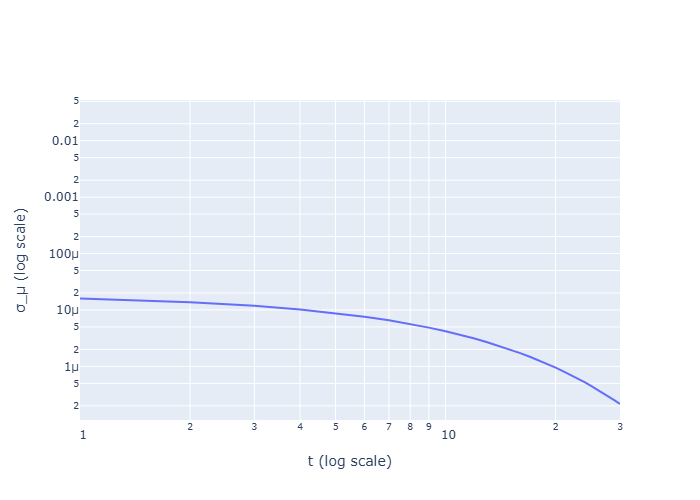

In [22]:
# log-log plot of std(μ) vs t
fig = go.Figure()
fig.add_trace(go.Scatter(x=t, y=mu_t_A0_star.std(axis=(-1,-2)), mode='lines'))
fig.update_layout(
  xaxis=dict(
      title="t (log scale)",
      type="log",
      showgrid=True
  ),
  yaxis=dict(
      title="σ_μ (log scale)",
      type="log",
      showgrid=True
  ),
)
fig.show()